# PatchCore WRN50 120k Modal Results Review

This notebook loads the latest local Modal artifact bundle for the labeled `120k / 10k / 20k` PatchCore WideResNet50-2 run and summarizes the final evaluation.

It is meant to be a lightweight review notebook for:
- the selected variant and threshold
- the comparison sweep across WRN50 PatchCore settings
- held-out test metrics on the `20k` evaluation split
- the main false positive and false negative tables


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

cwd = Path.cwd().resolve()
REPO_ROOT = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "outputs" / "modal_runs").exists() and (candidate / "notebooks" / "anomaly_120k_labeled" / "patchcore_wrn50").exists():
        REPO_ROOT = candidate
        break

if REPO_ROOT is None:
    raise RuntimeError("Could not locate the repository root for the PatchCore WRN50 120k results notebook.")

RESULTS_ROOT = REPO_ROOT / "outputs" / "modal_runs"
RUN_FOLDER_NAME = None  # Set this to a specific run folder if you want to inspect an older export.
RUN_CANDIDATES = sorted(RESULTS_ROOT.glob("patchcore_wrn50_120k_*"), reverse=True)

if not RUN_CANDIDATES:
    raise FileNotFoundError(f"No local Modal run folders were found under {RESULTS_ROOT}.")

RUN_ROOT = RESULTS_ROOT / RUN_FOLDER_NAME if RUN_FOLDER_NAME else RUN_CANDIDATES[0]
ARTIFACT_DIR = RUN_ROOT / "patchcore_wrn50_multilayer_120k_5pct"
EXECUTED_NOTEBOOK = RUN_ROOT / "executed_notebooks" / "18_patchcore_wideresnet50_multilayer_training_ran.ipynb"

if not ARTIFACT_DIR.exists():
    raise FileNotFoundError(f"Artifact directory not found: {ARTIFACT_DIR}")

print("Repo root:", REPO_ROOT)
print("Run root:", RUN_ROOT)
print("Artifact dir:", ARTIFACT_DIR)
print("Executed notebook:", EXECUTED_NOTEBOOK)


Repo root: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project
Run root: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\outputs\modal_runs\patchcore_wrn50_120k_20260320
Artifact dir: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\outputs\modal_runs\patchcore_wrn50_120k_20260320\patchcore_wrn50_multilayer_120k_5pct
Executed notebook: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\outputs\modal_runs\patchcore_wrn50_120k_20260320\executed_notebooks\18_patchcore_wideresnet50_multilayer_training_ran.ipynb


In [2]:
summary = json.loads((ARTIFACT_DIR / "bundle_summary.json").read_text(encoding="utf-8"))
sweep_df = pd.read_csv(ARTIFACT_DIR / "patchcore_sweep_results.csv").sort_values("f1", ascending=False).reset_index(drop=True)
selected_variant = str(summary["selected_variant"])
selected_row = sweep_df.loc[sweep_df["name"] == selected_variant].iloc[0]
predictions_path = ARTIFACT_DIR / f"{selected_variant}_test_predictions.csv"
pred_df = pd.read_csv(predictions_path)

run_info_df = pd.DataFrame(
    [
        {"item": "selected_variant", "value": selected_variant},
        {"item": "validation_threshold", "value": f"{selected_row['threshold']:.6f}"},
        {"item": "run_root", "value": str(RUN_ROOT)},
        {"item": "artifact_dir", "value": str(ARTIFACT_DIR)},
        {"item": "predictions_path", "value": str(predictions_path)},
    ]
)
split_config_df = pd.DataFrame(summary["split_config"].items(), columns=["split_setting", "value"])
sweep_view_df = sweep_df[
    [
        "name",
        "reduction",
        "topk_ratio",
        "threshold",
        "precision",
        "recall",
        "f1",
        "auroc",
        "auprc",
        "best_sweep_threshold",
        "best_sweep_f1",
        "predicted_anomalies",
    ]
].copy()

display(run_info_df)
display(split_config_df)
display(sweep_view_df)


,item,value
0,selected_variant,topk_mb50k_r005
1,validation_threshold,0.559844
2,run_root,C:\Users\genso\Documents\College_Projects\Deep...
3,artifact_dir,C:\Users\genso\Documents\College_Projects\Deep...
4,predictions_path,C:\Users\genso\Documents\College_Projects\Deep...


,split_setting,value
0,train_total,120000
1,train_anomalies,6000
2,val_total,10000
3,val_anomalies,500
4,test_total,20000
5,test_anomalies,1000


,name,reduction,topk_ratio,threshold,precision,recall,f1,auroc,auprc,best_sweep_threshold,best_sweep_f1,predicted_anomalies
0,topk_mb50k_r005,topk_mean,0.05,0.559844,0.420555,0.712,0.528778,0.927347,0.538246,0.570984,0.561961,1693
1,topk_mb50k_r010,topk_mean,0.10,0.537042,0.419738,0.706,0.526473,0.920945,0.525701,0.547569,0.559006,1682
2,topk_mb50k_r015,topk_mean,0.15,0.522250,0.417722,0.693,0.521249,0.914510,0.511975,0.532679,0.547145,1659
3,mean_mb50k,mean,0.10,0.370635,0.377577,0.586,0.459248,0.876674,0.390267,0.370900,0.460692,1552


In [3]:
y_true = pred_df["is_anomaly"].astype(int)
y_pred = pred_df["predicted_is_anomaly"].astype(int)
y_score = pred_df["score"].astype(float)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

metrics_df = pd.DataFrame(
    [
        {"metric": "threshold", "value": float(selected_row["threshold"])},
        {"metric": "precision", "value": precision_score(y_true, y_pred, zero_division=0)},
        {"metric": "recall", "value": recall_score(y_true, y_pred, zero_division=0)},
        {"metric": "f1", "value": f1_score(y_true, y_pred, zero_division=0)},
        {"metric": "accuracy", "value": accuracy_score(y_true, y_pred)},
        {"metric": "balanced_accuracy", "value": balanced_accuracy_score(y_true, y_pred)},
        {"metric": "auroc", "value": roc_auc_score(y_true, y_score)},
        {"metric": "auprc", "value": average_precision_score(y_true, y_score)},
        {"metric": "true_negatives", "value": int(tn)},
        {"metric": "false_positives", "value": int(fp)},
        {"metric": "false_negatives", "value": int(fn)},
        {"metric": "true_positives", "value": int(tp)},
        {"metric": "predicted_anomalies", "value": int(y_pred.sum())},
    ]
)

error_summary_df = pred_df["error_type"].value_counts().rename_axis("error_type").reset_index(name="count")
false_negative_by_type_df = (
    pred_df[(pred_df["is_anomaly"] == 1) & (pred_df["predicted_is_anomaly"] == 0)]["defect_type"]
    .value_counts()
    .rename_axis("defect_type")
    .reset_index(name="count")
)

display(metrics_df)
display(error_summary_df)
display(false_negative_by_type_df.head(10))


,metric,value
0,threshold,0.559844
1,precision,0.420555
2,recall,0.712000
3,f1,0.528778
4,accuracy,0.936550
5,balanced_accuracy,0.830184
6,auroc,0.927347
7,auprc,0.538246
8,true_negatives,18019.000000
9,false_positives,981.000000


,error_type,count
0,correct,18731
1,false_positive,981
2,false_negative,288


,defect_type,count
0,Center,111
1,Edge-Loc,72
2,Loc,65
3,Edge-Ring,21
4,Scratch,19


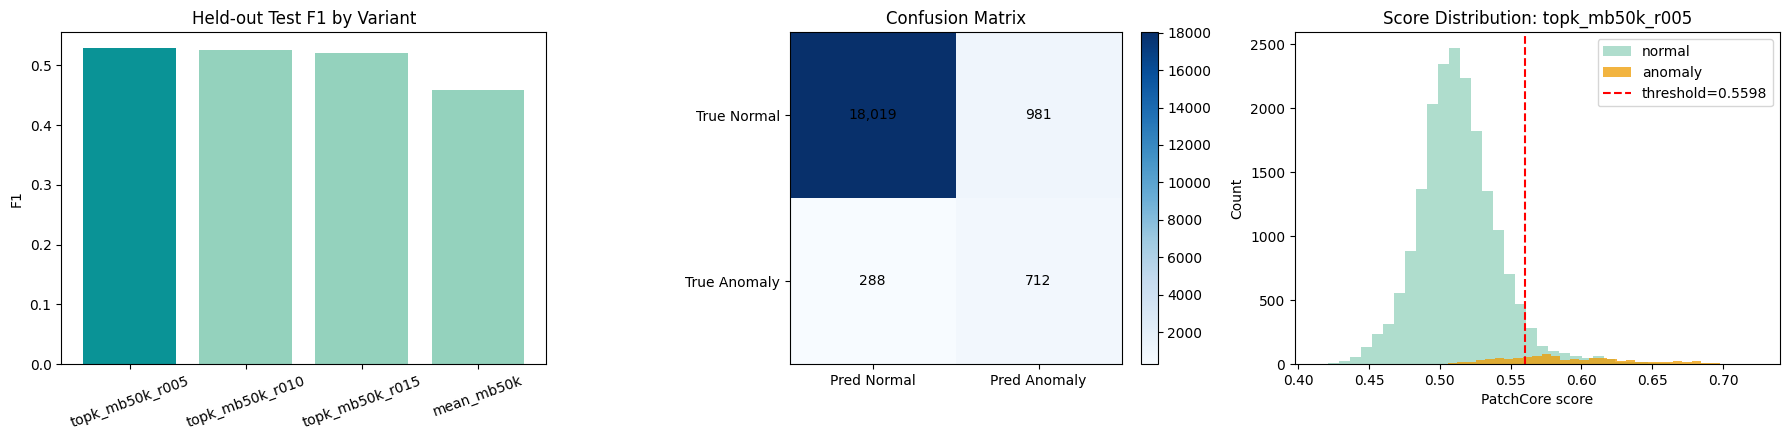

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

variant_colors = ["#0a9396" if name == selected_variant else "#94d2bd" for name in sweep_df["name"]]
axes[0].bar(sweep_df["name"], sweep_df["f1"], color=variant_colors)
axes[0].set_title("Held-out Test F1 by Variant")
axes[0].set_ylabel("F1")
axes[0].tick_params(axis="x", rotation=20)

cm = [[tn, fp], [fn, tp]]
image = axes[1].imshow(cm, cmap="Blues")
axes[1].set_title("Confusion Matrix")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Pred Normal", "Pred Anomaly"])
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["True Normal", "True Anomaly"])
for row_index in range(2):
    for col_index in range(2):
        axes[1].text(col_index, row_index, f"{cm[row_index][col_index]:,}", ha="center", va="center", color="black")
plt.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].hist(y_score[y_true == 0], bins=40, alpha=0.75, label="normal", color="#94d2bd")
axes[2].hist(y_score[y_true == 1], bins=40, alpha=0.75, label="anomaly", color="#ee9b00")
axes[2].axvline(float(selected_row["threshold"]), color="red", linestyle="--", label=f"threshold={selected_row['threshold']:.4f}")
axes[2].set_title(f"Score Distribution: {selected_variant}")
axes[2].set_xlabel("PatchCore score")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()


In [5]:
false_positive_df = pred_df[(pred_df["is_anomaly"] == 0) & (pred_df["predicted_is_anomaly"] == 1)].sort_values("score", ascending=False)
false_negative_df = pred_df[(pred_df["is_anomaly"] == 1) & (pred_df["predicted_is_anomaly"] == 0)].sort_values("score", ascending=True)

print("Top false positives")
display(false_positive_df[["array_path", "source_split", "score"]].head(10))

print("Top false negatives")
display(false_negative_df[["array_path", "defect_type", "source_split", "score"]].head(10))


Top false positives


,array_path,source_split,score
11673,processed/x64/wm811k_patchcore_custom/arrays_t...,Test,0.724708
9201,processed/x64/wm811k_patchcore_custom/arrays_t...,Training,0.691153
1128,processed/x64/wm811k_patchcore_custom/arrays_t...,Test,0.678940
6150,processed/x64/wm811k_patchcore_custom/arrays_t...,Training,0.676556
1808,processed/x64/wm811k_patchcore_custom/arrays_t...,Test,0.672534
545,processed/x64/wm811k_patchcore_custom/arrays_t...,Test,0.670359
8562,processed/x64/wm811k_patchcore_custom/arrays_t...,Test,0.669185
6086,processed/x64/wm811k_patchcore_custom/arrays_t...,Test,0.668909
6190,processed/x64/wm811k_patchcore_custom/arrays_t...,Test,0.664340
15354,processed/x64/wm811k_patchcore_custom/arrays_t...,Test,0.663744


Top false negatives


,array_path,defect_type,source_split,score
19392,processed/x64/wm811k_patchcore_custom/arrays_t...,Loc,Test,0.459138
19742,processed/x64/wm811k_patchcore_custom/arrays_t...,Loc,Training,0.462046
19977,processed/x64/wm811k_patchcore_custom/arrays_t...,Edge-Loc,Test,0.463717
19126,processed/x64/wm811k_patchcore_custom/arrays_t...,Loc,Training,0.469708
19553,processed/x64/wm811k_patchcore_custom/arrays_t...,Loc,Training,0.471506
19550,processed/x64/wm811k_patchcore_custom/arrays_t...,Loc,Training,0.473757
19929,processed/x64/wm811k_patchcore_custom/arrays_t...,Center,Training,0.479344
19050,processed/x64/wm811k_patchcore_custom/arrays_t...,Loc,Training,0.485009
19341,processed/x64/wm811k_patchcore_custom/arrays_t...,Loc,Training,0.488628
19619,processed/x64/wm811k_patchcore_custom/arrays_t...,Center,Test,0.492279
